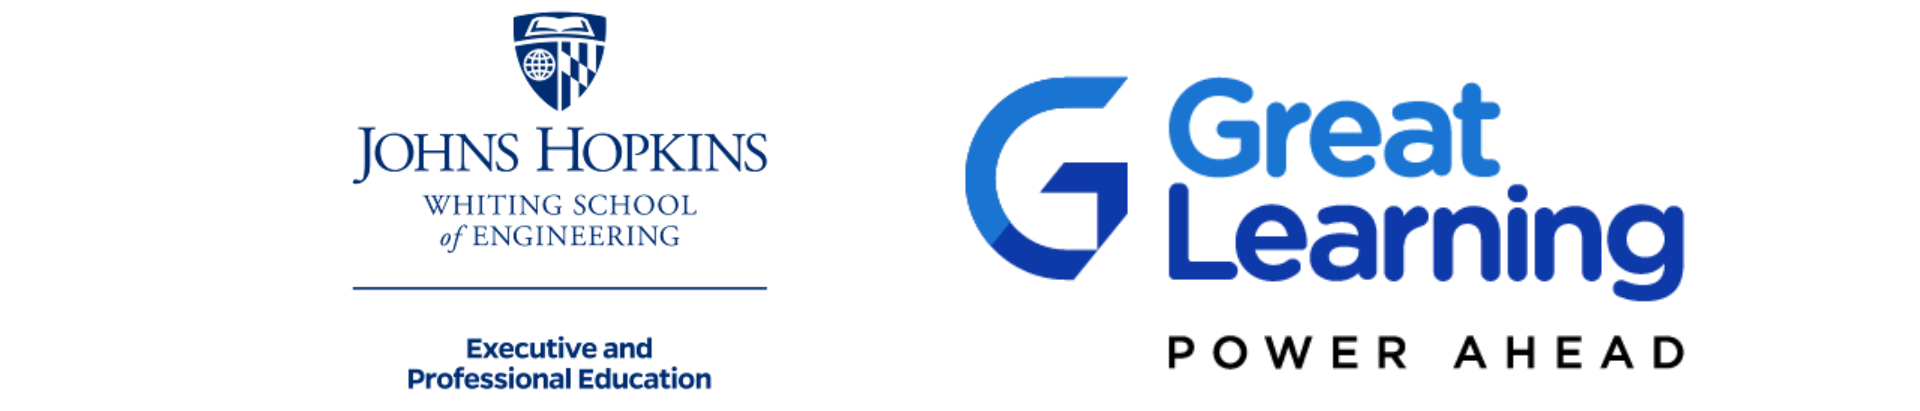


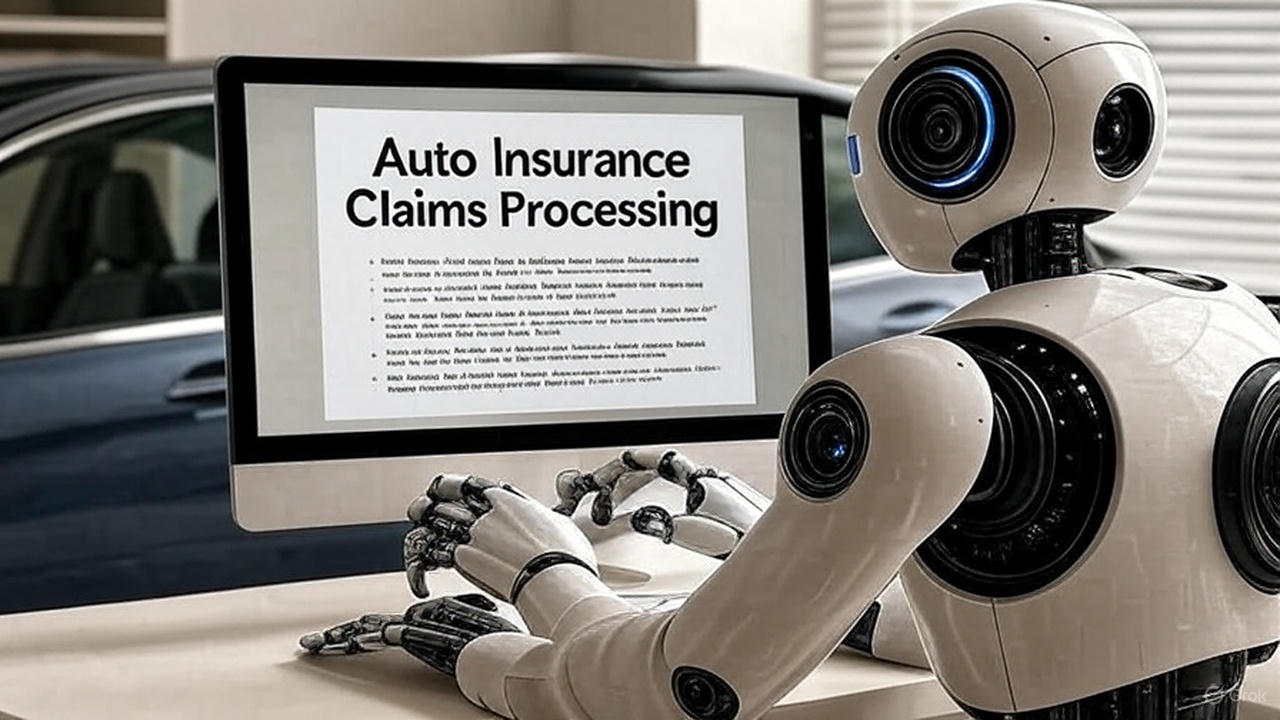


# Learning Objectives

- Implement a RAG-powered agentic application using the **smolagents** framework
- Understand how document chunking, embeddings, and vector retrieval work together in a RAG pipeline
- Learn how to define custom tools and orchestrate them with a `ToolCallingAgent`
- Practice structured output handling using Pydantic schemas and JSON mode
- Evaluate agent behavior across different claim scenarios


# Business Case: Auto Insurance Claims Processing

In the auto insurance industry, the claim process is predominantly manual. Claims executives manually parse invoices to extract key details, cross-reference vendor contracts to verify terms and compliance, and validate payments against policy stipulations. This process requires extensive review of complex policy documents, relying heavily on the executive's subject matter expertise and judgment to adjudicate claims.

## Problem Scenario

Due to its manual nature, claims processing is susceptible to delays. Policy documents are extensive and updated regularly, making it challenging for human operators to stay current with all changes. Manual errors, such as rejecting claims on invalid grounds, can lead to client frustration and dissatisfaction. Consequently, these inefficiencies lead to prolonged processing times, higher operational costs (in the long term), and potential reputational damage.

## Proposed Solution

The solution proposed is to develop an automated insurance claims processing system powered by Agentic Retrieval-Augmented Generation (Agentic RAG) capabilities. This solution embeds single AI agents with a knowledge base into a RAG pipeline. The system retrieves relevant policy details and integrates them with user claim data, validating claims through a web search against current policy information and regulations. It also generates adjudication recommendations while ensuring compliance with regulatory requirements.


## Why AgenticRAG Over Traditional RAG?

Traditional RAG systems rely on static workflows, limiting their adaptability for complex, multi-step tasks. AgenticRAG, however, uses agentic design patterns — **reflection**, **planning**, **tool use**, and **collaboration** — to dynamically manage retrieval, refine context, and adapt workflows. With flexible operational structures, from sequential to collaborative, AgenticRAG offers superior flexibility, scalability, and context-awareness, making it ideal for dynamic applications like automated claims processing.


## Design Decisions

Before diving into the code, here are the key technology choices made in this notebook and **why**:

| Component         | Choice                         | Rationale                                                                                               |
| ----------------- | ------------------------------ | ------------------------------------------------------------------------------------------------------- |
| Agent Framework   | `smolagents`                   | Lightweight, tool-based agent orchestration with built-in support for prompt templates and tool calling |
| LLM               | GPT-4o-mini                    | Good balance of cost and capability for structured reasoning tasks                                      |
| Embedding Model   | all-MiniLM-L6-v2               | Runs locally (no API cost), fast, and produces 384-dim vectors sufficient for our ~150 policy chunks    |
| Vector Database   | ChromaDB                       | Simple in-memory setup, no external services needed for a teaching notebook                             |
| Schema Validation | Pydantic v2                    | Type-safe data contracts between pipeline stages; catches data errors early                             |
| Text Chunking     | RecursiveCharacterTextSplitter | Handles varying document formats better than naive splitting; supports overlap for context continuity   |


# Claim Processing Notebook Overview

This notebook implements an automated claim processing workflow using a sequence of specialized tools orchestrated by an agent. The pipeline follows these steps:

1. **Parse Claim** (`parse_claim`) — Extract and validate claim data from a JSON file
2. **Validate Claim** (`validate_claim`) — Check policy existence, outstanding dues, and coverage dates
3. **Generate Queries** (`generate_policy_queries`) — Create targeted search queries for policy retrieval
4. **Retrieve Policy Text** (`retrieve_policy_text`) — Fetch relevant policy chunks from ChromaDB via semantic search
5. **Web Search** (built-in `WebSearchTool`) — Estimate real-world repair costs to detect inflated claims
6. **Generate Recommendation** (`generate_recommendation`) — Evaluate the claim against policy language
7. **Finalize Decision** (`finalize_decision`) — Produce a structured coverage decision with deductible and payout

The agent autonomously decides which tools to call and in what order, guided by the system prompt.


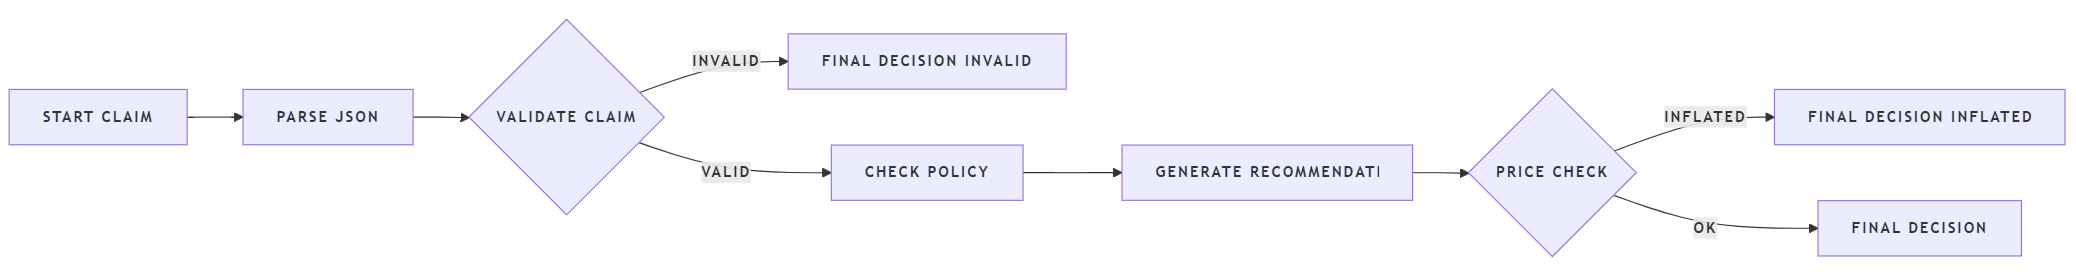


## Configuration

All tunable parameters are gathered in one place below. This makes it easy to experiment — change one value, re-run the notebook, and observe the effect.

**Try it yourself**: After running the notebook once, come back and change `n_results` from 3 to 1. How does it affect the quality of recommendations?


In [39]:
# ============================================================
# CONFIGURATION
# All tunable parameters in one place. Change these to
# experiment with different settings.
# ============================================================
CONFIG = {
    # --- Model Settings ---
    "llm_model_id": "gpt-4o-mini",  # OpenAI model for agent reasoning
    "embedding_model": "all-MiniLM-L6-v2",  # Local sentence embedding model (384-dim)
    # --- Chunking Settings ---
    "chunk_size": 800,  # Target characters per chunk (~150 words)
    "chunk_overlap": 100,  # Overlap between chunks to preserve context at boundaries
    # --- Retrieval Settings ---
    "n_results": 3,  # Number of chunks returned per query from ChromaDB
    "collection_name": "auto_insurance_policy",
    # --- Retry Settings ---
    "max_retries": 3,  # Max LLM call retries on failure
    "retry_delay": 1.0,  # Initial delay in seconds (doubles each retry)
    # --- File Paths ---
    "policy_pdf_path": "policy.pdf",
    "coverage_csv_path": "coverage_data.csv",
    "config_json_path": "../../config.json",
}

## Imports & Environment Setup


In [40]:
# Standard library
import csv
import datetime
import json
import os
import re
import time
from typing import List, Optional

# PDF processing
import PyPDF2

# Vector database
import chromadb

# Data validation
from pydantic import BaseModel, Field

# Sentence embeddings (runs locally, no API needed)
from sentence_transformers import SentenceTransformer

# Text chunking — handles varying document formats with configurable
# chunk sizes and overlap, unlike naive split() approaches
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Agent framework
from smolagents import (
    tool,
    ToolCallingAgent,
    WebSearchTool,
    OpenAIServerModel,
    PromptTemplates,
    PlanningPromptTemplate,
    ManagedAgentPromptTemplate,
    FinalAnswerPromptTemplate,
)

In [41]:
# Load API credentials from config file
with open(CONFIG["config_json_path"], "r") as f:
    config = json.load(f)
    os.environ["OPENAI_API_KEY"] = config.get("API_KEY")
    os.environ["OPENAI_BASE_URL"] = config.get("OPENAI_API_BASE")

## LLM Setup

We use **GPT-4o-mini** as the language model powering both the agent's reasoning and our tool-internal LLM calls. It offers a good balance between cost and capability for structured reasoning tasks like claim evaluation.


In [42]:
model = OpenAIServerModel(
    model_id=CONFIG["llm_model_id"],
    api_base=os.environ["OPENAI_BASE_URL"],
    api_key=os.environ["OPENAI_API_KEY"],
)

## Embedding Model

We use `all-MiniLM-L6-v2`, a lightweight sentence embedding model that maps text to 384-dimensional vectors. Key advantages for this notebook:

- **Runs locally** — no API calls, no cost per embedding
- **Fast** — processes our ~150 policy chunks in seconds
- **Good enough** — 384 dimensions capture semantic similarity well for document retrieval

For production with thousands of documents, you might prefer a larger model (e.g., OpenAI's `text-embedding-3-small`) for better accuracy.


In [43]:
embedder = SentenceTransformer(CONFIG["embedding_model"])

# Quick check: the embedding dimension should be 384
sample_embedding = embedder.encode("test sentence")
print(f"Embedding dimension: {len(sample_embedding)}")

Embedding dimension: 384


## Pydantic Schemas

Pydantic models serve as **data contracts** between pipeline stages. Each tool produces or consumes data validated against these schemas, ensuring that:

- Fields have the correct types (no string where a float is expected)
- Required fields are always present
- Data can be serialized to/from JSON consistently

Think of schemas as the "wiring diagram" that connects tools together.


In [44]:
# ClaimInfo is the ENTRY POINT of the pipeline.
# The parse_claim tool validates raw JSON against this schema,
# ensuring all downstream tools receive consistent, typed data.
class ClaimInfo(BaseModel):
    """Extracted insurance claim information."""

    claim_number: str
    policy_number: str
    claimant_name: str
    date_of_loss: str
    loss_description: str
    estimated_repair_cost: float
    vehicle_details: Optional[str] = None

In [45]:
# PolicyQueries is the OUTPUT of generate_policy_queries and
# INPUT to retrieve_policy_text. It ensures the LLM returns
# a clean list of search strings, not arbitrary JSON.
class PolicyQueries(BaseModel):
    queries: List[str] = Field(
        default_factory=list,
        description="A list of query strings to retrieve relevant policy sections.",
    )

In [46]:
# PolicyRecommendation bridges retrieval and decision-making.
# The generate_recommendation tool fills this with coverage analysis
# that finalize_decision uses to compute the payout.
class PolicyRecommendation(BaseModel):
    """Policy recommendation regarding a given claim."""

    policy_section: str = Field(
        ..., description="The policy section or clause that applies."
    )
    recommendation_summary: str = Field(
        ..., description="A concise summary of coverage determination."
    )
    deductible: Optional[float] = Field(
        None, description="The applicable deductible amount."
    )
    settlement_amount: Optional[float] = Field(
        None, description="Recommended settlement payout."
    )

In [47]:
# ClaimDecision is the FINAL OUTPUT of the pipeline.
# It is the structured answer the agent returns to the user.
class ClaimDecision(BaseModel):
    claim_number: str
    covered: bool
    deductible: float
    recommended_payout: float
    notes: Optional[str] = None

## Knowledge Base Setup (ChromaDB)

We use ChromaDB as an in-memory vector database to store and retrieve policy document chunks. The setup has three steps:

1. **Initialize** the ChromaDB client and create a collection
2. **Load** the policy PDF, split it into overlapping chunks
3. **Embed** each chunk and store it in the collection

This is the "knowledge base" that makes our system a RAG system — without it, the LLM would have to guess about policy terms.


In [48]:
# Initialize ChromaDB — runs in-memory (data is lost when kernel restarts)
chroma_client = chromadb.Client()
collection = chroma_client.get_or_create_collection(name=CONFIG["collection_name"])

### Document Chunking

RAG systems retrieve _relevant pieces_ of a document, not the whole thing. To enable this, we split the policy PDF into overlapping text chunks.

- **chunk_size=800**: Each chunk is ~800 characters (~150 words). Small enough to be specific, large enough to contain a complete thought.
- **chunk_overlap=100**: Adjacent chunks share 100 characters. This prevents important sentences from being split across chunk boundaries.

**Why not just split on paragraphs?** PDF text extraction often produces inconsistent newline patterns. For example, the policy PDF in this notebook contains zero double-newlines (`\n\n`), so a naive `split("\n\n")` would produce a **single 97K-character chunk** — defeating the purpose of retrieval entirely. `RecursiveCharacterTextSplitter` handles these edge cases gracefully.


In [49]:
# Load the policy PDF and extract all text
with open(CONFIG["policy_pdf_path"], "rb") as f:
    reader = PyPDF2.PdfReader(f)
    policy_text = ""
    for page in reader.pages:
        text = page.extract_text()
        if text:  # Some pages may return None
            policy_text += text

print(f"Extracted {len(policy_text):,} characters from {len(reader.pages)} pages")

# Split into overlapping chunks using RecursiveCharacterTextSplitter
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=CONFIG["chunk_size"],
    chunk_overlap=CONFIG["chunk_overlap"],
    separators=["\n", ". ", " ", ""],  # Try newline first, then sentence boundary
)
policy_chunks = text_splitter.split_text(policy_text)

print(f"Created {len(policy_chunks)} chunks")

Extracted 96,906 characters from 28 pages
Created 139 chunks


In [50]:
# Quick diagnostic: verify chunks are reasonable size
chunk_sizes = [len(c) for c in policy_chunks]
print(
    f"Chunk sizes: min={min(chunk_sizes)}, max={max(chunk_sizes)}, avg={sum(chunk_sizes)//len(chunk_sizes)}"
)
print(f"\nSample chunk (chunk 5):\n{policy_chunks[5][:300]}...")

Chunk sizes: min=225, max=798, avg=756

Sample chunk (chunk 5):
TRUST AGREEMENT  ................................................ 9 
ARBITRATION  ............................................................ 9 
PART D COVERAGE FOR DAMAGE  
TO YOUR AUTO  ............................................................. 9 
INSURING AGREEMENT - COLLISION  .................


In [51]:
# Embed all chunks and store them in ChromaDB
chunk_ids = [f"chunk_{i}" for i in range(len(policy_chunks))]
chunk_embeddings = embedder.encode(policy_chunks).tolist()

collection.add(
    documents=policy_chunks,
    embeddings=chunk_embeddings,
    ids=chunk_ids,
)

print(
    f"Stored {len(policy_chunks)} chunks in ChromaDB collection '{CONFIG['collection_name']}'"
)

Stored 139 chunks in ChromaDB collection 'auto_insurance_policy'


## Helper Utilities

Before defining our tools, we create two helper functions that eliminate code duplication:

1. **`parse_llm_json()`** — Parses LLM text output into a validated Pydantic model. Handles common LLM quirks like wrapping JSON in markdown code fences.
2. **`call_llm_with_retry()`** — Calls the LLM with automatic retry and exponential backoff. Optionally enforces structured JSON output.

**Why helpers?** Without these, every tool that calls the LLM needs ~40 lines of boilerplate for JSON parsing, error handling, and retry logic. With helpers, each tool focuses on its actual business logic in ~10 lines.


In [52]:
def parse_llm_json(response_content: str, pydantic_model: type[BaseModel]) -> BaseModel:
    """
    Parse LLM response text into a validated Pydantic model.

    Handles common LLM output quirks:
    - Markdown code fences (```json ... ```)
    - ChatMessage objects vs raw strings

    Args:
        response_content: Raw text from the LLM response.
        pydantic_model: The Pydantic class to validate against.

    Returns:
        A validated instance of pydantic_model.

    Raises:
        ValueError: If JSON parsing or schema validation fails.
    """
    text = response_content.strip()

    # Strip markdown code fences if the LLM wrapped its response
    if text.startswith("```"):
        text = text.split("\n", 1)[1] if "\n" in text else text[3:]
    if text.endswith("```"):
        text = text[:-3].strip()

    data = json.loads(text)
    return pydantic_model.model_validate(data)

In [53]:
def call_llm_with_retry(
    prompt: str,
    pydantic_model: type[BaseModel] | None = None,
    max_retries: int = CONFIG["max_retries"],
    retry_delay: float = CONFIG["retry_delay"],
) -> str | BaseModel:
    """
    Call the LLM with retry logic and optional structured output validation.

    When pydantic_model is provided, uses JSON response format to ensure
    the LLM returns valid JSON, then validates against the schema.
    Implements exponential backoff: waits 1s, 2s, 4s between retries.

    Args:
        prompt: The user message to send to the LLM.
        pydantic_model: If provided, parse and validate response.
        max_retries: Number of retry attempts.
        retry_delay: Initial delay between retries in seconds.

    Returns:
        Validated Pydantic model instance, or raw response string.

    Raises:
        RuntimeError: If all retry attempts fail.
    """
    messages = [{"role": "user", "content": prompt}]
    last_error = None

    for attempt in range(max_retries):
        try:
            # Use JSON mode when we need structured output —
            # this tells the LLM to return valid JSON, eliminating
            # most parsing errors at the source
            response = model(
                messages,
                response_format={"type": "json_object"} if pydantic_model else None,
            )
            content = (
                response.content if hasattr(response, "content") else str(response)
            )

            if pydantic_model:
                return parse_llm_json(content, pydantic_model)
            return content

        except Exception as e:
            last_error = e
            if attempt < max_retries - 1:
                wait = retry_delay * (2**attempt)  # Exponential backoff: 1s, 2s, 4s
                print(f"  Retry {attempt + 1}/{max_retries} after {wait}s: {e}")
                time.sleep(wait)

    raise RuntimeError(
        f"LLM call failed after {max_retries} attempts. Last error: {last_error}"
    )

## Tool Definitions

Each tool in the pipeline is a Python function decorated with `@tool` from smolagents. The decorator converts the function into a tool that the agent can call, using the function's name, docstring, and type hints to describe its capabilities.

Tools communicate by passing JSON strings — the output of one tool becomes the input to the next. Pydantic schemas ensure these JSON strings have the expected structure.


### Tool 1: Parse Claim

The entry point of the pipeline. Reads a JSON file containing claim data and validates it against the `ClaimInfo` schema. This ensures all downstream tools receive clean, consistently structured data.

**Input**: File path (string)
**Output**: JSON string matching `ClaimInfo` schema


In [54]:
@tool
def parse_claim(file_path: str) -> str:
    """
    Parse a claim JSON file and return structured ClaimInfo data.

    Args:
        file_path (str): Path to the JSON file containing claim data.
    """
    try:
        with open(file_path, "r") as f:
            data = json.load(f)

        # Validate against schema — catches missing/wrong-type fields early
        claim_info = ClaimInfo.model_validate(data)
        return claim_info.model_dump_json()

    except Exception as e:
        return f"Error parsing claim: {str(e)}"

### Tool 2: Validate Claim

Checks whether the claim meets basic eligibility criteria by looking up the policy in `coverage_data.csv`. Three checks are performed:

1. **Policy exists** — Is the policy number in our records?
2. **No outstanding dues** — Are premium payments up to date?
3. **Date in coverage period** — Did the loss occur while the policy was active?

If any check fails, the tool returns `{"valid": false, "reason": "..."}` and the agent should stop processing.

**Input**: JSON string matching `ClaimInfo` schema
**Output**: JSON string with `valid` (bool) and `reason` (str) fields


In [55]:
@tool
def validate_claim(claim_info_json: str) -> str:
    """
    Validate a parsed insurance claim against policy records.

    Args:
        claim_info_json (str): JSON string of ClaimInfo data from parse_claim.
    """
    try:
        claim_info = ClaimInfo.model_validate_json(claim_info_json)

        # Load policy records from CSV
        coverage_data = []
        with open(CONFIG["coverage_csv_path"], "r", newline="", encoding="utf-8") as f:
            reader = csv.DictReader(f)
            for row in reader:
                coverage_data.append(row)
    except Exception as e:
        return json.dumps({"valid": False, "reason": f"Error loading data: {str(e)}"})

    # Check 1: Does the policy exist in our records?
    policy = next(
        (p for p in coverage_data if p["policy_number"] == claim_info.policy_number),
        None,
    )
    if policy is None:
        return json.dumps({"valid": False, "reason": "Policy not found in records."})

    # Check 2: Are premium dues paid up?
    # CSV stores booleans as strings ("True"/"False"), so we compare lowercase.
    # NOTE: The original notebook had a bug here — it used "claim_dues_remaining"
    # instead of the actual column name "premium_dues_remaining". Because dict.get()
    # silently returns "" when the key is missing, the bug was invisible.
    dues_remaining = policy.get("premium_dues_remaining", "").strip().lower()
    if dues_remaining in ("true", "1", "yes"):
        return json.dumps(
            {"valid": False, "reason": "Outstanding premium dues on this policy."}
        )

    # Check 3: Did the loss occur within the coverage period?
    date_of_loss = datetime.datetime.strptime(claim_info.date_of_loss, "%Y-%m-%d")
    coverage_start = datetime.datetime.strptime(
        policy["coverage_start_date"], "%Y-%m-%d"
    )
    coverage_end = datetime.datetime.strptime(policy["coverage_end_date"], "%Y-%m-%d")

    if not (coverage_start <= date_of_loss <= coverage_end):
        return json.dumps(
            {
                "valid": False,
                "reason": "Date of loss falls outside the coverage period.",
            }
        )

    return json.dumps({"valid": True, "reason": "Claim passes all validation checks."})

### Tool 3: Generate Policy Queries

Analyzes the claim details and generates 3-5 targeted search queries to retrieve relevant policy sections. For example, a rear-end collision claim might generate queries about "collision coverage", "deductible amounts", and "liability exclusions".

This tool calls the LLM directly (via `call_llm_with_retry`) and validates the output against the `PolicyQueries` schema.

**Input**: JSON string matching `ClaimInfo` schema
**Output**: JSON string matching `PolicyQueries` schema


In [56]:
@tool
def generate_policy_queries(claim_info_json: str) -> str:
    """
    Generate queries to retrieve relevant policy sections based on claim info.

    Args:
        claim_info_json (str): JSON string of ClaimInfo data.
    """
    prompt = f"""
    Analyze the following auto insurance claim and identify 3-5 key policy
    sections to consult. Focus on collision coverage, liability, deductibles,
    and relevant exclusions or endorsements.

    Claim Data: {claim_info_json}

    Return a JSON object with a 'queries' field containing a list of strings.
    Example: {{"queries": ["collision coverage terms", "deductible schedule", "exclusions for commercial use"]}}
    """

    # call_llm_with_retry handles JSON mode, retries, and schema validation
    result = call_llm_with_retry(prompt, pydantic_model=PolicyQueries)
    return result.model_dump_json()

### Tool 4: Retrieve Policy Text

This is the **RAG retrieval step**. It takes the generated queries, converts each to an embedding, and searches ChromaDB for the most similar policy chunks. Results are deduplicated (the same chunk may match multiple queries) and concatenated.

**Input**: JSON string matching `PolicyQueries` schema
**Output**: Concatenated policy text (plain string)
**Key parameter**: `CONFIG["n_results"]` controls how many chunks per query


In [57]:
@tool
def retrieve_policy_text(queries_json: str) -> str:
    """
    Retrieve policy text from ChromaDB based on generated queries.

    Args:
        queries_json (str): JSON string of PolicyQueries data.
    """
    try:
        queries_data = json.loads(queries_json)
        queries = PolicyQueries.model_validate(queries_data)
    except Exception as e:
        return f"Error parsing queries: {str(e)}"

    # Retrieve chunks for each query, deduplicating across queries.
    # We query separately per query string rather than batching because
    # each query targets different policy sections — batching would
    # average the embeddings together and reduce precision.
    seen = set()
    policy_texts = []

    for query_str in queries.queries:
        query_embedding = embedder.encode([query_str])[0].tolist()
        results = collection.query(
            query_embeddings=[query_embedding],
            n_results=CONFIG["n_results"],
        )

        # Deduplicate: the same chunk may match multiple queries
        for chunk in results["documents"][0]:
            if chunk not in seen:
                seen.add(chunk)
                policy_texts.append(chunk)
        print(
            f"  Retrieved {len(results['documents'][0])} chunks for: {query_str[:60]}..."
        )

    print(f"  Total unique chunks retrieved: {len(policy_texts)}")
    return "\n\n---\n\n".join(policy_texts)

### Tool 5: Generate Recommendation

Evaluates the claim against the retrieved policy text using the LLM. The model determines whether the collision is covered, identifies the applicable policy section, and recommends deductible and settlement amounts.

The output is validated against `PolicyRecommendation` schema using `call_llm_with_retry`, which ensures consistent structured output.

**Input**: ClaimInfo JSON + retrieved policy text
**Output**: JSON string matching `PolicyRecommendation` schema


In [58]:
@tool
def generate_recommendation(claim_info_json: str, policy_text: str) -> str:
    """
    Generate a policy recommendation based on claim info and retrieved policy text.

    Args:
        claim_info_json (str): JSON string of ClaimInfo data.
        policy_text (str): Retrieved policy text from ChromaDB.
    """
    prompt = f"""
    Evaluate the following auto insurance claim against the policy text.
    Determine if the collision is covered, the applicable deductible,
    recommended settlement amount, and which policy section applies.

    Claim Info: {claim_info_json}

    Policy Text: {policy_text}

    Return a JSON object with exactly these fields:
    {{
        "policy_section": "string - the specific policy section or clause",
        "recommendation_summary": "string - concise coverage determination",
        "deductible": null or float,
        "settlement_amount": null or float
    }}
    """

    # call_llm_with_retry enforces JSON mode and validates against PolicyRecommendation
    result = call_llm_with_retry(prompt, pydantic_model=PolicyRecommendation)
    return result.model_dump_json()

### Tool 6: Finalize Decision

The final evaluation stage. Takes the validated claim info and the policy recommendation, determines coverage status, and produces a structured `ClaimDecision` with the claim number, coverage boolean, deductible, payout, and explanatory notes.

**Input**: ClaimInfo JSON + PolicyRecommendation JSON
**Output**: JSON string matching `ClaimDecision` schema


In [59]:
@tool
def finalize_decision(claim_info_json: str, recommendation_json: str) -> str:
    """
    Finalize the claim decision based on the recommendation.

    Args:
        claim_info_json (str): JSON string of ClaimInfo data.
        recommendation_json (str): JSON string of PolicyRecommendation.
    """
    try:
        claim_info = ClaimInfo.model_validate_json(claim_info_json)
        rec = parse_llm_json(recommendation_json, PolicyRecommendation)
    except Exception as e:
        return f"Error parsing inputs: {str(e)}"

    # Determine coverage based on the recommendation.
    # We check for positive signals in the summary and settlement amount.
    covered = "covered" in rec.recommendation_summary.lower() or (
        rec.settlement_amount is not None and rec.settlement_amount > 0
    )

    decision = ClaimDecision(
        claim_number=claim_info.claim_number,
        covered=covered,
        deductible=rec.deductible or 0.0,
        recommended_payout=rec.settlement_amount or 0.0,
        notes=rec.recommendation_summary,
    )
    return decision.model_dump_json()

## Prompt Setup

Prompts guide the agent's behavior. In smolagents, they are organized into categories:

- **System Prompt**: Sets the overall context, rules, and step-by-step instructions the agent must follow
- **Planning Prompt**: Helps the agent reflect on known facts and plan its next actions
- **Managed Agent Prompt**: For sub-agents in multi-agent setups (not used here)
- **Final Answer Prompt**: Formats the agent's final response

The system prompt below defines a **mandatory 7-step sequence** for claim processing. The agent will follow this sequence, calling tools in order.


In [60]:
system_prompt = """
You are an expert insurance claim-processing agent specializing in
auto insurance. You follow a strict, multi-step reasoning process.

CLAIM PROCESSING ORDER (MANDATORY):

  1. Parse the claim JSON to extract all ClaimInfo fields using parse_claim.

  2. Validate the claim using validate_claim:
     - If the result shows valid=false, STOP immediately and return
       the reason as your final answer.

  3. Generate policy-related search queries using generate_policy_queries.

  4. Retrieve relevant policy text from the knowledge base using retrieve_policy_text.

  5. Use the web_search tool to estimate typical repair costs:
     - Search for market repair price ranges for the described damage.
     - Compare the estimated cost to the claimed amount.
     - If the claimed amount is unrealistically high (e.g., 3x or more
       above market estimates), return a rejection as your final answer.

  6. Generate a coverage recommendation using generate_recommendation,
     based on the validated claim, retrieved policy text, and cost estimate.

  7. Produce the final claim decision using finalize_decision.

ALWAYS follow this exact sequence. Do not reorder, skip, or combine steps.
"""

planning_prompts = PlanningPromptTemplate(
    initial_facts=(
        """
        Claim details:
        {claim_info_json}

        Policy details:
        {policy_text}

        Recommendation (if any):
        {recommendation_json}
        """
    ),
    initial_plan=(
        """
        1. Parse the claim JSON and extract all ClaimInfo fields.

        2. Validate the claim:
           - Call validate_claim with the extracted ClaimInfo.
           - If valid=false, STOP and return an invalid-claim response.

        3. Generate policy search queries based on the claim details.

        4. Retrieve relevant policy sections from ChromaDB using those queries.

        5. Estimate repair cost:
           - Use the web_search tool to research typical repair prices for
             the specific type of damage.
           - Compare estimated market price with the claimed amount.
           - If the claim amount is unreasonable or inflated,
             return an invalid-claim result.

        6. Using claim details, policy text, and repair-cost estimate,
           create a coverage recommendation.

        7. Produce the final claim decision in the required output format.
        """
    ),
    update_facts_pre_messages="Reassess claim and policy facts with new information:",
    update_facts_post_messages="The facts have been updated.",
    update_plan_pre_messages="Revise the plan based on updated facts:",
    update_plan_post_messages="Plan updated.",
)

managed_agent_prompts = ManagedAgentPromptTemplate(
    task=(
        "Process the following auto insurance claim: {task_description}. "
        "Follow the structured claim-processing workflow exactly as defined."
    ),
    report=("Generate the final claim decision using the processed results: {results}"),
)

final_answer_prompts = FinalAnswerPromptTemplate(
    pre_messages=(
        "Using the output from the finalize_decision tool, format the final claim decision "
        "EXACTLY as shown below — do not add prose, explanations, or extra text:\n\n"
        "Claim Processing Summary:\n\n"
        "- Claim Number: <claim_number>\n"
        "- Coverage Status: Valid  (if covered is true)  OR  Invalid  (if covered is false)\n"
        "- Deductible: $<deductible formatted to 2 decimal places>\n"
        "- Recommended Payout: $<recommended_payout formatted to 2 decimal places>\n"
        "- Notes: <notes>"
    ),
    post_messages=(
        "Output must strictly follow the format above. "
        "Coverage Status must be exactly 'Valid' or 'Invalid'. "
        "Dollar amounts must be formatted as $X.XX. "
        "Do not include any other text."
    ),
    final_answer_template=(
        """
        Claim Decision
        -------------------------
        Claim Number: {claim_number}
        Covered: {covered}
        Deductible: {deductible}
        Recommended Payout: {recommended_payout}

        Notes:
        {notes}
        """
    ),
)

prompt_templates = PromptTemplates(
    system_prompt=system_prompt,
    planning=planning_prompts,
    managed_agent=managed_agent_prompts,
    final_answer=final_answer_prompts,
)

## Agent Assembly

The `ToolCallingAgent` orchestrates the entire pipeline. It receives a task (a file path), reasons about which tool to call next, and passes data between tools. The `add_base_tools=True` flag adds built-in utilities like `web_search`.

Note: The agent uses the system prompt to guide its tool-calling order, but it is ultimately an LLM making decisions — it may occasionally deviate from the prescribed sequence.


In [61]:
claim_processing_agent = ToolCallingAgent(
    tools=[
        parse_claim,
        validate_claim,
        WebSearchTool(),
        generate_policy_queries,
        retrieve_policy_text,
        generate_recommendation,
        finalize_decision,
    ],
    model=model,
    add_base_tools=True,
    prompt_templates=prompt_templates,
)

In [ ]:
def format_result(result, claim_file: str) -> str:
    """
    Normalize agent output into a consistent Claim Decision summary.

    The agent sometimes calls finalize_decision (returning JSON) and sometimes
    short-circuits with a plain-text rejection. This function handles both cases
    and always returns the same structured format.
    """
    # Read the claim number from the source file so we can always populate it
    try:
        with open(claim_file) as _f:
            _claim_number = json.load(_f).get("claim_number", "UNKNOWN")
    except Exception:
        _claim_number = "UNKNOWN"

    raw = str(result).strip()

    # --- Case 1: result is a JSON object from finalize_decision ---
    try:
        # The agent may embed JSON anywhere in its final answer; extract it
        json_match = re.search(r"\{.*\}", raw, re.DOTALL)
        if json_match:
            data = json.loads(json_match.group())
            covered = data.get("covered", False)
            status = "Approved" if covered else "Invalid"
            deductible = data.get("deductible", 0.0) or 0.0
            payout = data.get("recommended_payout", 0.0) or 0.0
            notes = data.get("notes", raw)
            claim_num = data.get("claim_number", _claim_number)
            return (
                f"Claim Decision:\n"
                f"- Claim Number: {claim_num}\n"
                f"- Coverage Status: {status}\n"
                f"- Deductible: ${deductible:.2f}\n"
                f"- Recommended Payout: ${payout:.2f}\n"
                f"- Notes: {notes}"
            )
    except (json.JSONDecodeError, AttributeError):
        pass

    # --- Case 2: plain-text rejection / early exit ---
    return (
        f"Claim Decision:\n"
        f"- Claim Number: {_claim_number}\n"
        f"- Coverage Status: Invalid\n"
        f"- Deductible: $0.00\n"
        f"- Recommended Payout: $0.00\n"
        f"- Notes: {raw}"
    )

## Test Runs

We test four scenarios that exercise different parts of the pipeline:

| Run | Scenario                                 | Expected Outcome          | Tests Which Component                  |
| --- | ---------------------------------------- | ------------------------- | -------------------------------------- |
| 1   | Invalid policy number (PL-1)             | Rejected at validation    | `validate_claim` — policy lookup       |
| 2   | Inflated repair cost ($5,000 for bumper) | Rejected after web search | `WebSearchTool` — price reasonableness |
| 3   | Valid claim, reasonable cost ($550)      | Approved with payout      | Full pipeline end-to-end               |
| 4   | Outstanding premium dues (PN-3)          | Rejected at validation    | `validate_claim` — dues check          |

After each run, compare the output to the expected outcome. If they differ, that is a learning opportunity — investigate why the agent behaved differently.


### Run 1: Invalid Policy Number

Policy number **PL-1** does not exist in `coverage_data.csv` (valid numbers are PN-1 through PN-10). The agent should call `parse_claim`, then `validate_claim`, which returns `valid=false`. The agent should then stop and report the rejection without calling any further tools.


In [62]:
ema_claim_data = {
    "claim_number": "CLAIM-00001",
    "policy_number": "PL-1",
    "claimant_name": "Ema Johnson",
    "date_of_loss": "2022-01-21",
    "loss_description": "Rear-ended by another driver at a red light, resulting in bumper damage and mild whiplash.",
    "estimated_repair_cost": 150.0,
    "vehicle_details": "2022 Honda City",
}

with open("ema.json", "w") as f:
    json.dump(ema_claim_data, f)

print("Created ema.json — policy PL-1 (not in coverage_data.csv)")

Created ema.json — policy PL-1 (not in coverage_data.csv)


In [63]:
result = claim_processing_agent.run("Process the claim in ema.json")

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Process the claim in ema.json                                                                                   │
│                                                                                                                 │
╰─ OpenAIModel - gpt-4o-mini ─────────────────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'parse_claim' with arguments: {'file_path': 'ema.json'}                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Observations: {"claim_number":"CLAIM-00001","policy_number":"PL-1","claimant_name":"Ema 
Johnson","date_of_loss":"2022-01-21","loss_description":"Rear-ended by another driver at a red light, resulting in 
bumper damage and mild whiplash.","estimated_repair_cost":150.0,"vehicle_details":"2022 Honda City"}

[Step 1: Duration 1.68 seconds| Input tokens: 754 | Output tokens: 16]

...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 3 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'final_answer' with arguments: {'answer': 'Claim processing stopped: Policy not found in          │
│ records.'}                                                                                                      │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Observations: Claim processing stopped: Policy not found in records.

Final answer: Claim processing stopped: Policy not found in records.

[Step 3: Duration 1.98 seconds| Input tokens: 2,711 | Output tokens: 133]

In [75]:
print(format_result(result, "ema.json"))

Claim Decision:
- Claim Number: CLAIM-00001
- Coverage Status: Invalid
- Deductible: $0.00
- Recommended Payout: $0.00
- Notes: Claim processing stopped: Policy not found in records.


### Analysis: Run 1

**Expected**: The agent calls `parse_claim` then `validate_claim` and stops with "Policy not found."

**What to look for in the trace above**:

- Did the agent call only 2 tools (parse + validate)?
- Did it correctly identify that PL-1 is not a valid policy?
- Did it avoid calling `generate_policy_queries` or any downstream tools?

If the agent continued past validation anyway, this demonstrates a key challenge in agentic systems: the LLM may not always follow instructions perfectly, even with a clear system prompt.


### Run 2: Inflated Claim Amount

This claim uses a valid policy (PN-1) and valid dates, but the repair cost is **$5,000** for minor bumper damage. The agent should pass validation, generate queries, retrieve policy text, then use `web_search` to check typical repair costs. Upon finding that bumper repairs typically cost $300-800, it should reject the claim as inflated.


In [65]:
ema_claim_data_2 = {
    "claim_number": "CLAIM-00002",
    "policy_number": "PN-1",
    "claimant_name": "Ema Johnson",
    "date_of_loss": "2022-01-21",
    "loss_description": "Rear-ended by another driver at a red light, resulting in bumper damage and mild whiplash.",
    "estimated_repair_cost": 5000.0,
    "vehicle_details": "2022 Honda City",
}

with open("ema2.json", "w") as f:
    json.dump(ema_claim_data_2, f)

print("Created ema2.json — valid policy PN-1 but inflated cost ($5,000)")

Created ema2.json — valid policy PN-1 but inflated cost ($5,000)


In [66]:
result2 = claim_processing_agent.run("Process the claim in ema2.json")

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Process the claim in ema2.json                                                                                  │
│                                                                                                                 │
╰─ OpenAIModel - gpt-4o-mini ─────────────────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'parse_claim' with arguments: {'file_path': 'ema2.json'}                                          │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Observations: {"claim_number":"CLAIM-00002","policy_number":"PN-1","claimant_name":"Ema 
Johnson","date_of_loss":"2022-01-21","loss_description":"Rear-ended by another driver at a red light, resulting in 
bumper damage and mild whiplash.","estimated_repair_cost":5000.0,"vehicle_details":"2022 Honda City"}

[Step 1: Duration 1.73 seconds| Input tokens: 755 | Output tokens: 17]

...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 7 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'final_answer' with arguments: {'answer': 'Claim rejected: the claimed amount of $5000.0 is       │
│ significantly higher than the typical upper bound of repair costs which is $2500. This amount is more than 3    │
│ times the market estimate, indicating an unrealistic claim.'}                                                   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Observations: Claim rejected: the claimed amount of $5000.0 is significantly higher than the typical upper bound of
repair costs which is $2500. This amount is more than 3 times the market estimate, indicating an unrealistic claim.

Final answer: Claim rejected: the claimed amount of $5000.0 is significantly higher than the typical upper bound of
repair costs which is $2500. This amount is more than 3 times the market estimate, indicating an unrealistic claim.

[Step 7: Duration 2.74 seconds| Input tokens: 17,325 | Output tokens: 427]

In [76]:
print(format_result(result2, "ema2.json"))

Claim Decision:
- Claim Number: CLAIM-00002
- Coverage Status: Invalid
- Deductible: $0.00
- Recommended Payout: $0.00
- Notes: Claim rejected: the claimed amount of $5000.0 is significantly higher than the typical upper bound of repair costs which is $2500. This amount is more than 3 times the market estimate, indicating an unrealistic claim.


### Analysis: Run 2

**Expected**: The agent processes through validation and retrieval, then uses web search to detect the inflated cost and rejects the claim.

**What to look for**:

- Did the agent call `web_search` to check repair costs?
- Did it compare the web search results ($300-800 typical) against the claimed $5,000?
- Did it reject the claim based on the price mismatch?

Note: Web search results are non-deterministic — your results may vary between runs.


### Run 3: Valid Claim (Full Pipeline)

This is a complete, realistic claim that should pass every stage. Policy PN-1 is valid, dates are within coverage, no outstanding dues, and the $550 repair cost for bumper damage is reasonable. The agent should process through all 7 steps and return an approved decision with deductible and payout.


In [68]:
ema_claim_data_3 = {
    "claim_number": "CLAIM-00003",
    "policy_number": "PN-1",
    "claimant_name": "Ema Johnson",
    "date_of_loss": "2022-01-21",
    "loss_description": "The car was rear ended by a truck when parked at the office. The rear bumper was destroyed in the process.",
    "estimated_repair_cost": 550.0,
    "vehicle_details": "2022 Honda City",
}

with open("ema3.json", "w") as f:
    json.dump(ema_claim_data_3, f)

print("Created ema3.json — valid policy PN-1, reasonable cost ($550)")

Created ema3.json — valid policy PN-1, reasonable cost ($550)


In [69]:
result3 = claim_processing_agent.run("Process the claim in ema3.json")

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Process the claim in ema3.json                                                                                  │
│                                                                                                                 │
╰─ OpenAIModel - gpt-4o-mini ─────────────────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'parse_claim' with arguments: {'file_path': 'ema3.json'}                                          │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Observations: {"claim_number":"CLAIM-00003","policy_number":"PN-1","claimant_name":"Ema 
Johnson","date_of_loss":"2022-01-21","loss_description":"The car was rear ended by a truck when parked at the 
office. The rear bumper was destroyed in the process.","estimated_repair_cost":550.0,"vehicle_details":"2022 Honda 
City"}

[Step 1: Duration 1.35 seconds| Input tokens: 755 | Output tokens: 17]

...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 9 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'final_answer' with arguments: {'answer': 'The claim for Ema Johnson has been approved. The       │
│ recommended payout is $550.00, as the collision is covered under the policy since it involved a parked car      │
│ being hit by another vehicle. There is no deductible for this claim.'}                                          │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Observations: The claim for Ema Johnson has been approved. The recommended payout is $550.00, as the collision is 
covered under the policy since it involved a parked car being hit by another vehicle. There is no deductible for 
this claim.

Final answer: The claim for Ema Johnson has been approved. The recommended payout is $550.00, as the collision is 
covered under the policy since it involved a parked car being hit by another vehicle. There is no deductible for 
this claim.

[Step 9: Duration 2.16 seconds| Input tokens: 29,253 | Output tokens: 935]

In [ ]:
print(format_result(result3, "ema3.json"))

The claim for Ema Johnson has been approved. The recommended payout is $550.00, as the collision is covered under the policy since it involved a parked car being hit by another vehicle. There is no deductible for this claim.


### Analysis: Run 3

**Expected**: Full pipeline execution — approved claim with deductible and payout.

**What to look for**:

- Did the agent follow all 7 steps in order?
- Does the final decision include a specific `deductible` and `recommended_payout`?
- Does the `policy_section` reference an actual part of the policy document?
- Is the `notes` field a clear explanation of the coverage determination?


### Run 4: Outstanding Premium Dues

Policy **PN-3** has `premium_dues_remaining=True` in `coverage_data.csv`. Even though the date of loss falls within the coverage period, the claim should be rejected because the policyholder has not paid their premiums.

This test verifies that the dues validation logic works correctly.


In [71]:
ema_claim_data_4 = {
    "claim_number": "CLAIM-00004",
    "policy_number": "PN-3",
    "claimant_name": "David Park",
    "date_of_loss": "2021-09-15",
    "loss_description": "Hail damage to windshield and hood during a severe storm.",
    "estimated_repair_cost": 1200.0,
    "vehicle_details": "2020 Toyota Camry",
}

with open("ema4.json", "w") as f:
    json.dump(ema_claim_data_4, f)

print("Created ema4.json — policy PN-3 has outstanding dues")

Created ema4.json — policy PN-3 has outstanding dues


In [72]:
result4 = claim_processing_agent.run("Process the claim in ema4.json")

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Process the claim in ema4.json                                                                                  │
│                                                                                                                 │
╰─ OpenAIModel - gpt-4o-mini ─────────────────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'parse_claim' with arguments: {'file_path': 'ema4.json'}                                          │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Observations: {"claim_number":"CLAIM-00004","policy_number":"PN-3","claimant_name":"David 
Park","date_of_loss":"2021-09-15","loss_description":"Hail damage to windshield and hood during a severe 
storm.","estimated_repair_cost":1200.0,"vehicle_details":"2020 Toyota Camry"}

[Step 1: Duration 1.06 seconds| Input tokens: 755 | Output tokens: 17]

...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 3 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'final_answer' with arguments: {'answer': 'Claim cannot be processed due to outstanding premium   │
│ dues on this policy.'}                                                                                          │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Observations: Claim cannot be processed due to outstanding premium dues on this policy.

Final answer: Claim cannot be processed due to outstanding premium dues on this policy.

[Step 3: Duration 1.29 seconds| Input tokens: 2,692 | Output tokens: 130]

In [ ]:
print(format_result(result4, "ema4.json"))

Claim cannot be processed due to outstanding premium dues on this policy.


### Analysis: Run 4

**Expected**: The agent calls `parse_claim` then `validate_claim` and stops with "Outstanding premium dues."

**What to look for**:

- Did `validate_claim` catch the outstanding dues on PN-3?
- Did the agent stop without proceeding to query generation?

**Note on the original notebook**: The original version of this code had a bug where the CSV column name was misspelled (`claim_dues_remaining` instead of `premium_dues_remaining`). Because Python's `dict.get()` returns a default value silently when the key is missing, this bug was invisible — dues validation _always_ passed. This is a good example of why silent defaults can mask bugs. Using `dict["key"]` (which raises `KeyError`) would have surfaced this issue immediately during testing.


## Conclusion

### What We Built

An agentic RAG system that processes auto insurance claims through a 7-step pipeline: parse, validate, query, retrieve, web-search, recommend, decide. The agent autonomously decides which tools to call and in what order, guided by the system prompt.

### Key Takeaways

1. **Proper chunking is essential** — Without correct text splitting, RAG degrades to "context stuffing" where the entire document is retrieved every time. `RecursiveCharacterTextSplitter` with overlap handles real-world PDF formatting reliably.

2. **Structured output eliminates boilerplate** — Using `response_format={"type": "json_object"}` and Pydantic validation replaces hundreds of lines of manual JSON parsing and type-checking with clean, maintainable code.

3. **System prompts guide but don't guarantee behavior** — The agent generally follows the 7-step sequence, but LLMs may occasionally deviate. This is a fundamental property of agentic systems.

4. **Pydantic schemas act as contracts** — When tools communicate via validated JSON, bugs are caught at the boundaries rather than deep inside business logic.

5. **Silent defaults hide bugs** — Using `.get(key, default)` instead of `[key]` can mask errors for a long time (as we saw with the CSV column name bug in the original notebook).

### Limitations

- The agent may not always follow the prescribed tool order
- Web search results are non-deterministic and may vary between runs
- The "covered" determination uses keyword matching, not true legal policy reasoning
- ChromaDB runs in-memory — data is lost when the kernel restarts

### Future Work

To quantify system quality, the following evaluation metrics could be implemented:

- **Context Precision**: Of the chunks retrieved, how many were relevant to the claim?
- **Context Recall**: Of the relevant chunks in the document, how many were retrieved?
- **Answer Correctness**: Does the final decision match a human adjuster's decision?

These require a labeled test set (ground-truth decisions for a set of claims), which would be the natural next step in a production system.
